In [1]:
import os
os.environ['EXO_LD_PATH'] = '/Users/tylergordon/research/exotic_ld_data'

import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
sys.path.append('../get_planet_params/')
from fit_wlc import check_initial_state, prep_data
from scipy.ndimage import gaussian_filter1d
from wlc_utils import build_mask, gls_fit

In [2]:
files = ['/Users/tylergordon/research/toi455_eureka/reduction/nrs1/stage3/S3_2026-01-05_toi455_nrs1_run10/ap4_bg9/S3_toi455_nrs1_ap4_bg9_SpecData.h5']

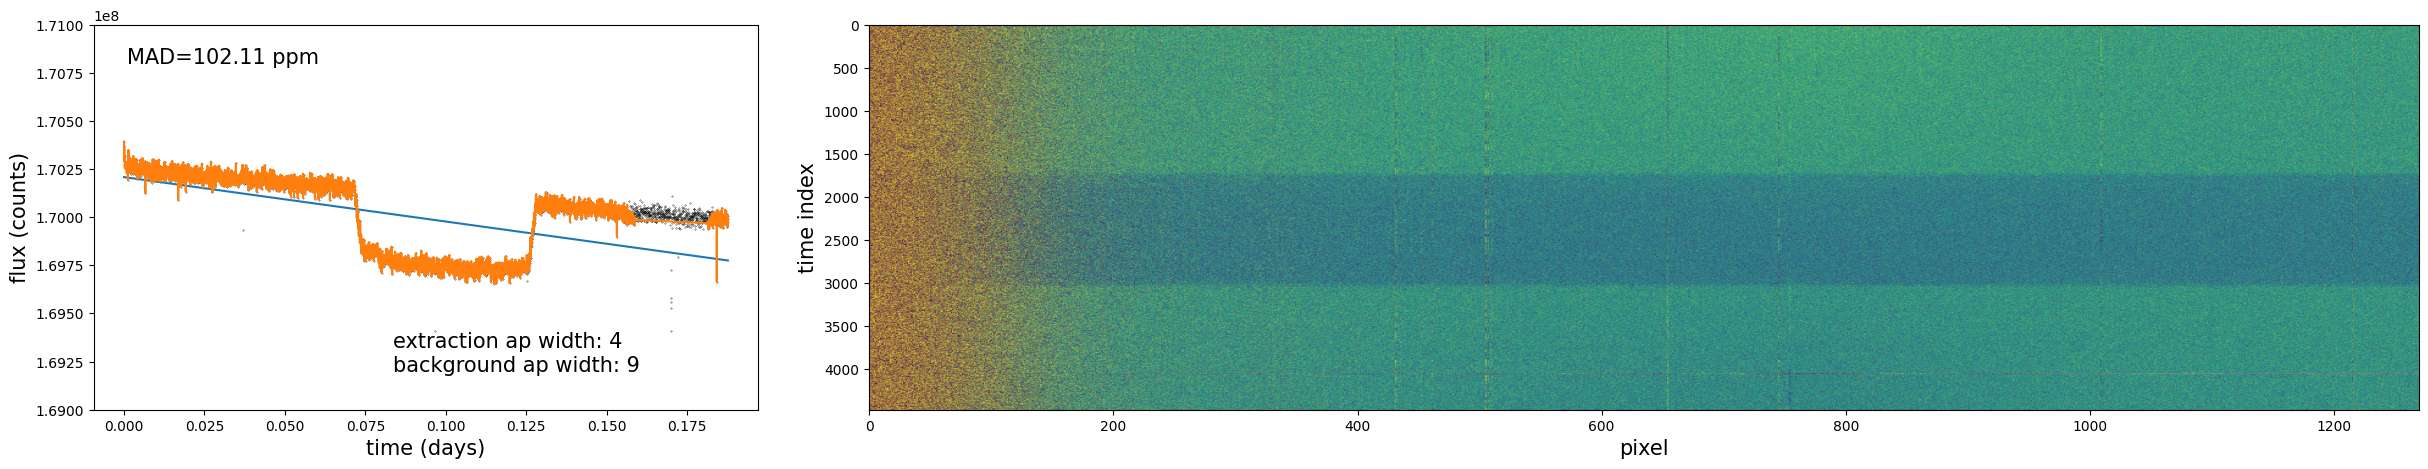

In [14]:
from fit_wlc import check_initial_state, prep_data

for file in files:
    
    if 'nrs1' in file:
        detector = 'nrs1'
    elif 'nrs2' in file:
        detector = 'nrs2'
    else:
        raise Error('file is not a g395h reduction ')

    target = files[0].split('/')[-7].replace('_', ' ')
    #program, visit = files[0].split('/')[-6].split('_')
    #info_string = '{}\ntarget: {}\nvisit: {}'.format(target, program, visit)
    ap, bg = [f[2:] for f in files[0].split('/')[-2].split('_')]
    reduction_string = 'extraction ap width: {}\nbackground ap width: {}'.format(ap, bg)
    
    control_dict = {
        'pipeline': 'eureka',
        'data_directories': [file],
        'detector': 'nrs2',
        'polyorder': 1,
        'columns_to_mask': []
    }
    
    time, spect, err, _, spec, flux, _ = prep_data(control_dict)
    time = time[0]
    spect = spect[0]
    err = err[0]
    spec = spec[0]
    flux = flux[0]
    
    mask = build_mask(flux)
    coeffs, fit = gls_fit(
        time, 
        flux, 
        [], 
        mask, 
        polyorder=1, 
        return_coeffs=True
    )

    med = gaussian_filter1d(flux, 20)
    mad = np.median(np.abs(flux - med)) / coeffs[0] * 1e6

    fig, axs = plt.subplots(1, 2, figsize=(25, 5), gridspec_kw={'hspace': 0.2, 'wspace': 0.1, 'width_ratios':(0.3, 0.7)})

    axs[0].plot(time, flux, 'k.', markersize=0.5)
    axs[1].imshow(spect / np.nanmedian(spect, axis=0), aspect='auto', vmin=0.99, vmax=1.01)
    #axs[0].annotate(info_string, xy=(0.05, 0.1), xycoords='axes fraction', fontsize=15)
    axs[0].annotate(reduction_string, xy=(0.45, 0.1), xycoords='axes fraction', fontsize=15)
    axs[0].plot(time, fit)
    axs[0].set_ylim(1.69e8, 1.71e8)
    axs[0].plot(time[~mask], flux[~mask])
    axs[0].annotate('MAD={:0.2f} ppm'.format(mad), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=15)
    
    h = np.max(flux) - np.min(flux)
    #axs[0].set_ylim(np.min(flux) - h / 2, np.max(flux) + h / 10)
    axs[0].set_xlabel('time (days)', fontsize=15)
    axs[0].set_ylabel('flux (counts)', fontsize=15)
    axs[1].set_xlabel('pixel', fontsize=15)
    axs[1].set_ylabel('time index', fontsize=15)
    plt.subplots_adjust(left=0.04, right=0.97)
    #plt.savefig('{}_{}_{}_{}.pdf'.format(target, program, visit, detector))

In [8]:
coeffs

array([ 1.70208346e+08, -2.30816210e+06])

In [ ]:
# build control dictionaries for each lightcurve (just one if not using G395H)
control_dict_nrs1 = {
    
    # eureka or jedi
    'pipeline': 'eureka',
    
    'priors': priors,
    'stellar_parameters': st_params,
    
    # this is the directory that all the input files are located in
    'data_directories': [
        '/Users/tylergordon/research/HBM/volga/TOI-178_b/2319_3/nrs1/stage3/S3_2026-02-02_nrs1_run1/ap4_bg9/S3_nrs1_ap4_bg9_SpecData.h5'
    ],
    
    # use this to mask any columns that look like they got a bad background subtraction
    'columns_to_mask': [],
    
    # for G395H, will need to add support for other detectors/dispersers 
    'detector': 'nrs1',
    
    # number of MCMC samples and number to crop off beginning of chains for burn-in
    'samples': 10_000,
    'burnin': 5_000,
    
    # number of processors to use: 2 seems to be best on my computer for some reason.
    'num_proc': 2,
    
    # order of a polynomial trend for the out-of-transit flux 
    'polyorder': 1,
    
    # whether to show the MCMC progress bar or not 
    'show_progress_bar': True,
    
    # number of processors to use for spectral lightcurve fitting 
    'num_proc_slc': 12,
    
    # number of samples for white lightcurve fitting
    'samples_slc': 1000
}

control_dict_nrs2 = {
    'pipeline': 'eureka',
    'priors': priors,
    'stellar_parameters': st_params,
    'data_directories': [
        '/Users/tylergordon/research/HBM/volga/TOI-178_b/2319_3/nrs1/stage3/S3_2026-02-02_nrs1_run1/ap4_bg9/S3_nrs1_ap4_bg9_SpecData.h5'
    ],
    'columns_to_mask': [],
    'detector': 'nrs2',
    'samples': 10_000,
    'burnin': 5_000,
    'num_proc': 2,
    'polyorder': 1,
    'show_progress_bar': True,
    'num_proc_slc': 12,
    'samples_slc': 1000
}

In [ ]:
# plot the white lightcurves along with the model corresponding to the initial parameters for the MCMC fit 
# also plots the time vs. x-pixel images for identifying bad columns or other artifacts 

from fit_wlc import check_initial_state, prep_data

times_nrs1, spects_nrs1, errs_nrs1, _, specs_nrs1, flux_nrs1, _ = prep_data(control_dict_nrs1)
initial_models_nrs1 = check_initial_state(control_dict_nrs1)

times_nrs2, spects_nrs2, errs_nrs2, _, specs_nrs2, flux_nrs2, _ = prep_data(control_dict_nrs2)
initial_models_nrs2 = check_initial_state(control_dict_nrs2)

for i in range(len(times_nrs1)):
    
    fig, axs = plt.subplots(2, 2, figsize=(20, 5), gridspec_kw={'hspace': 0.2, 'wspace': 0.1, 'width_ratios':(0.2, 0.8)})
    
    axs[0, 0].plot(times_nrs1[i], initial_models_nrs1[i])
    axs[0, 0].plot(times_nrs1[i], flux_nrs1[i], 'k.', markersize=0.2)
    axs[0, 1].imshow(spects_nrs1[i] / np.nanmedian(spects_nrs1[i], axis=0), aspect='auto', vmin=0.99, vmax=1.01)

    axs[1, 0].plot(times_nrs2[i], initial_models_nrs2[i])
    axs[1, 0].plot(times_nrs2[i], flux_nrs2[i], 'k.', markersize=0.2)
    axs[1, 1].imshow(spects_nrs2[i] / np.nanmedian(spects_nrs2[i], axis=0), aspect='auto', vmin=0.99, vmax=1.01)

In [ ]:
# run the fits once everything looks good 

wlc_res_nrs1 = fit(control_dict_nrs1)
wlc_res_nrs2 = fit(control_dict_nrs2)

In [ ]:
from fit_wlc import get_model_samples

fig, axs = plt.subplots(2, 2, figsize=(15, 4), gridspec_kw={'height_ratios': (0.6, 0.4), 'hspace': 0.0, 'wspace': 0.15}, sharex=True)

axs[0, 0].annotate('NRS1', fontsize=20, xy=(0.05, 0.1), xycoords='axes fraction')
axs[0, 1].annotate('NRS2', fontsize=20, xy=(0.05, 0.1), xycoords='axes fraction')

for res_nrs1, res_nrs2 in zip(wlc_res_nrs1, wlc_res_nrs2):
    
    models_nrs1 = get_model_samples(res_nrs1, n=100)

    axs[0, 0].plot(res_nrs1['time'], res_nrs1['flux'], '.', color=plt.cm.rainbow(0.1), markersize=1.0)
    [axs[0, 0].plot(res_nrs1['time'], m, color='k', alpha=0.3) for m in models_nrs1];
    axs[1, 0].plot(res_nrs1['time'], res_nrs1['flux'] - np.mean(models_nrs1, axis=0), '.', color=plt.cm.rainbow(0.1), markersize=1.0)

    models_nrs2 = get_model_samples(res_nrs2, n=100)

    axs[0, 1].plot(res_nrs2['time'], res_nrs2['flux'], '.', color=plt.cm.rainbow(0.1), markersize=1.0)
    [axs[0, 1].plot(res_nrs2['time'], m, color='k', alpha=0.3) for m in models_nrs2];
    axs[1, 1].plot(res_nrs2['time'], res_nrs2['flux'] - np.mean(models_nrs2, axis=0), '.', color=plt.cm.rainbow(0.1), markersize=1.0)

In [ ]:
import imp
import fit_slc
imp.reload(fit_slc)
from fit_slc import fit

slc_res_nrs1 = fit(wlc_res_nrs1)
slc_res_nrs2 = fit(wlc_res_nrs2)

In [ ]:
posteriors, binned_wavs = np.concatenate([posteriors_nrs1, posteriors_nrs2]), np.concatenate([binned_wavs_nrs1, binned_wavs_nrs2])

depths = np.array([np.median(p.get_chain()[5000:, :, 3]) for p in posteriors])
errs = np.array([np.std(p.get_chain()[5000:, :, 3]) for p in posteriors])

plt.plot(binned_wavs, depths**2 * 1e6, 'ko')
plt.errorbar(binned_wavs, depths**2 * 1e6, yerr=errs * 2 * depths * 1e6, ls='none', color='k')